# Exploratory Data Analysis (EDA) Part 1: Distributions & Outliers


## Step 1: Explore the Distribution of Numeric Variables

The dataset is loaded and all numeric columns are identified automatically.

The `Row ID` and `Postal Code` columns were removed because they do not provide meaningful information for analysis.  
`Row ID` is only a unique identifier, and `Postal Code` represents location codes rather than numerical features.

A histogram is then generated for each numeric variable to visualize its distribution. Histograms help reveal:

- The overall shape of the distribution.
- Whether the data is symmetric or skewed.
- The spread of the values.
- Potential outliers or unusual patterns.

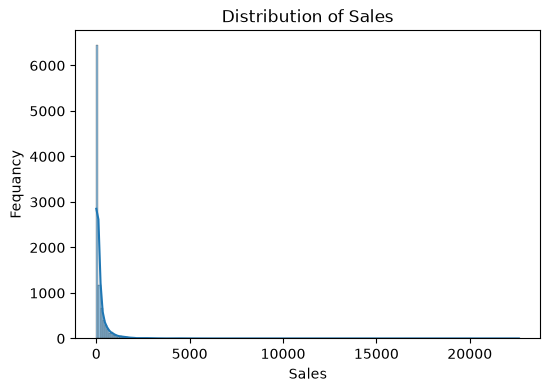

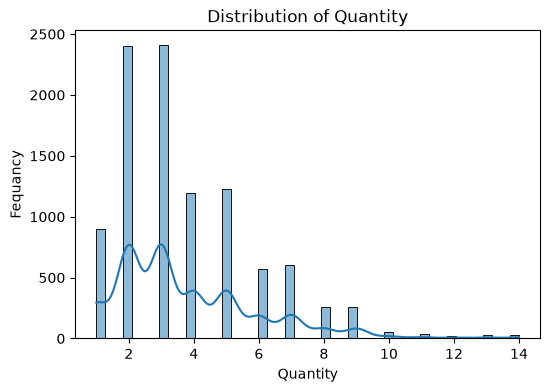

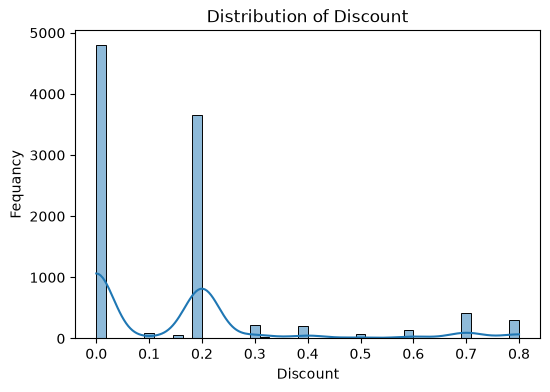

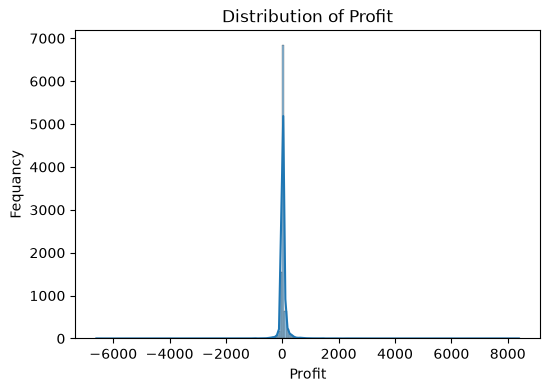

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("Superstore.csv", encoding="ISO-8859-1")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop(["Row ID", "Postal Code"])
for col in numeric_cols:
    plt.figure(figsize=(6,4))  

    # Add a KDE curve to better visualize the overall distribution shape.
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Fequancy")
    plt.show()

### Results
- **Sales** is highly right-skewed, meaning most sales transactions have relatively small values, while only a few transactions have very large sales.
- **Quantity** is concentrated between **2 and 3 items**, with larger order quantities occurring much less frequently.
- **Discount** is heavily concentrated around **0.0** and **0.2**, indicating that most orders receive either no discount or a small discount.
- **Profit** is strongly centered near zero, with only a small number of transactions generating very large profits or losses.

## Step 2: Visualize Outliers Using Box Plots

Box plots are created for every numeric feature to summarize each variable's distribution.

Each box plot displays:

- The median.
- The interquartile range (IQR).
- The minimum and maximum non-outlier values.
- Any potential outliers as individual points.

These plots provide a quick visual indication of extreme values that may require further investigation.

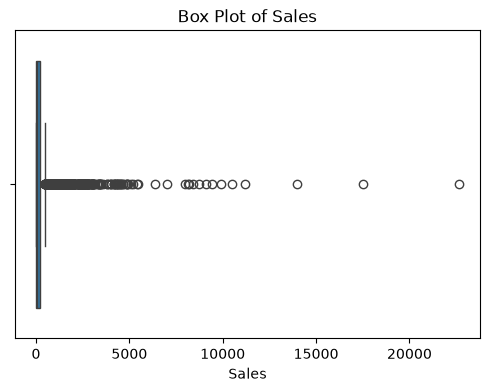

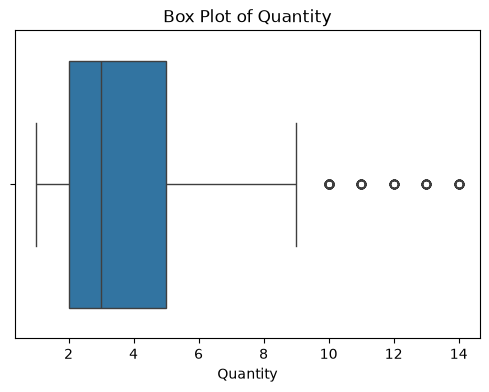

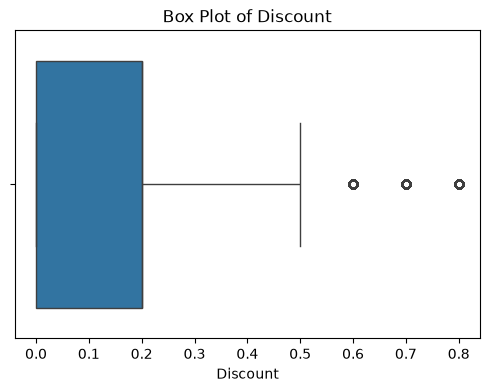

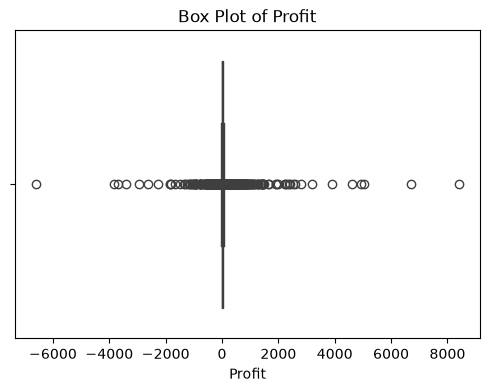

In [2]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.show()

### Results
- **Sales** contains many high-value outliers, indicating a small number of exceptionally large transactions.
- **Quantity** has a few outliers for large order quantities (approximately 10–14 items), while most orders contain fewer items.
- **Discount** includes several high-discount outliers (around 0.6–0.8), although most discounts remain below 0.2.
- **Profit** contains numerous outliers on both the positive and negative sides, confirming the presence of unusually high profits and significant losses. This supports applying the IQR method in the next step.

## Step 3: Detect Outliers Using the IQR Method

To identify outliers programmatically, the Interquartile Range (IQR) method is applied to the **Profit** column.

The following steps are performed:

1. Calculate the first quartile (Q1).
2. Calculate the third quartile (Q3).
3. Compute the IQR as (Q3 − Q1).
4. Determine the lower and upper bounds.
5. Flag values outside these bounds as potential outliers.

This statistical approach provides an objective way to detect unusually high or low values.

In [43]:
profit=df["Profit"]
Q1 = profit.quantile(0.25)
Q3 = profit.quantile(0.75)

IQR= Q3 - Q1
LB = Q1- (1.5 * IQR)
UB = Q3 +(1.5 * IQR)

outliers= df[(profit<LB) | (profit>UB)]
print("Outliers =", outliers)

print("Number of outliers:", len(outliers))

Outliers =       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
7          8  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
10        11  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
13        14  CA-2016-161389   12/5/2016  12/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9957    9958  US-2014-143287  11/11/2014  11/17/2014  Standard Class   
9962    9963  CA-2015-168088   3/19/2015   3/22/2015     First Class   
9968    9969  CA-2017-153871  12/11/2017  12/17/2017  Standard Class   
9979    9980  US-2016-103674   12/6/2016  12/10/2016  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name      Segment        Country  \
1       CG-12520       Claire Gute     Consumer  United St

### Handling the Detected Outliers

Instead of removing observations, the detected outliers are handled using **Winsorization (Capping)**.

Values below the lower bound are replaced with the lower bound, while values above the upper bound are replaced with the upper bound.

This approach preserves all records while reducing the influence of extreme values on future analysis and machine learning models.

In [45]:

df["Profit_Capped"] = profit.clip(
    lower=LB,
    upper=UB
)

### Box Plot After Outlier Treatment

The updated box plot is generated after applying the capping process.

Comparing this visualization with the original box plot helps confirm that extreme values have been successfully limited while maintaining the overall distribution.

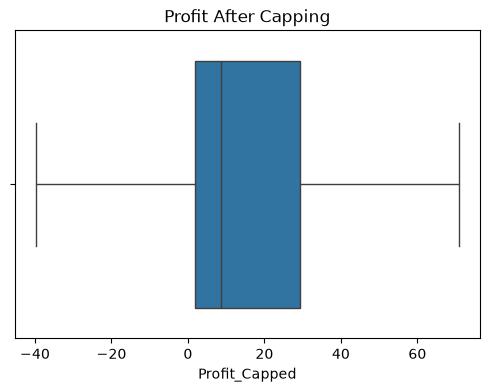

In [46]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Profit_Capped"])
plt.title("Profit After Capping")
plt.show()

### Original Distribution Before Treatment

This box plot shows the original **Profit** distribution before handling outliers.

Comparing it with the capped version illustrates the effect of the IQR-based treatment on extreme observations.

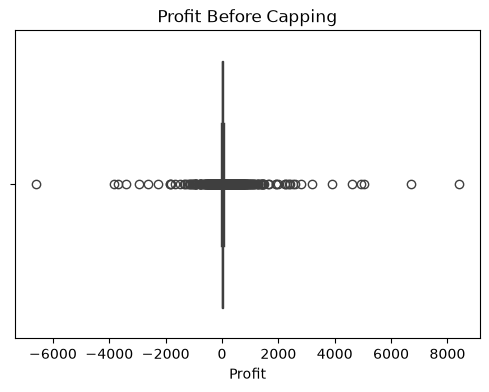

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Profit"])
plt.title("Profit Before Capping")
plt.show()

### Results

- The updated box plot shows that the most extreme values have been limited.
- The overall distribution remains similar, but the influence of outliers has been reduced.
- This confirms that the capping process was successfully applied.

## Step 4: Analyze Categorical Variables

This step explores the distribution of categorical features using count plots.

Since some categorical columns contain a very large number of unique values, only variables with fewer than **20 unique categories** are selected. This makes the visualizations easier to read and interpret while allowing class imbalance to be identified more clearly.

### Selecting Categorical Columns

First, all categorical columns are identified. Then, only columns with fewer than **20 unique values** are kept to improve the readability of the count plots.

In [51]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols = [
    col for col in categorical_cols 
    if df[col].nunique() < 20
]

categorical_cols

C:\Users\MOSAB PC\AppData\Local\Temp\ipykernel_27864\3917428803.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


['Ship Mode', 'Segment', 'Country', 'Region', 'Category', 'Sub-Category']

### Creating Count Plots

Count plots are generated for the selected categorical variables to visualize the frequency of each category and identify any class imbalance.

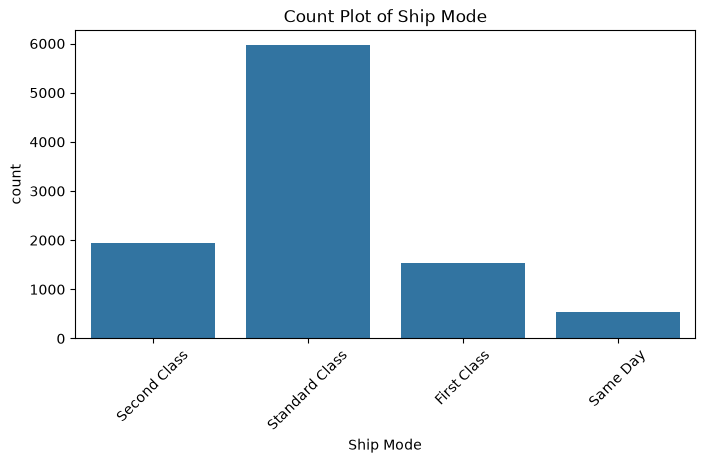

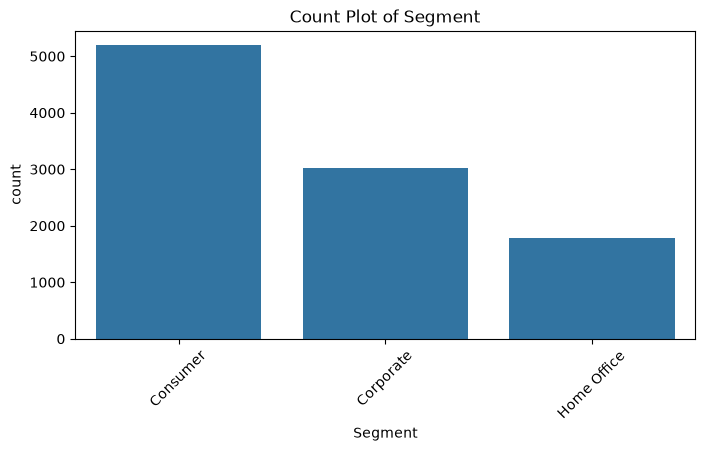

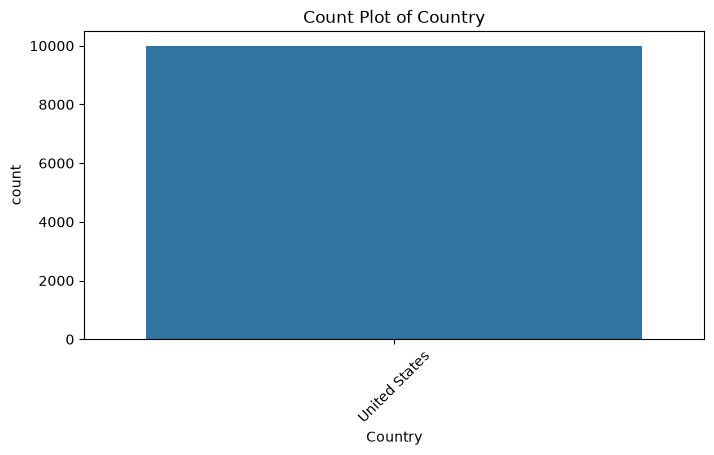

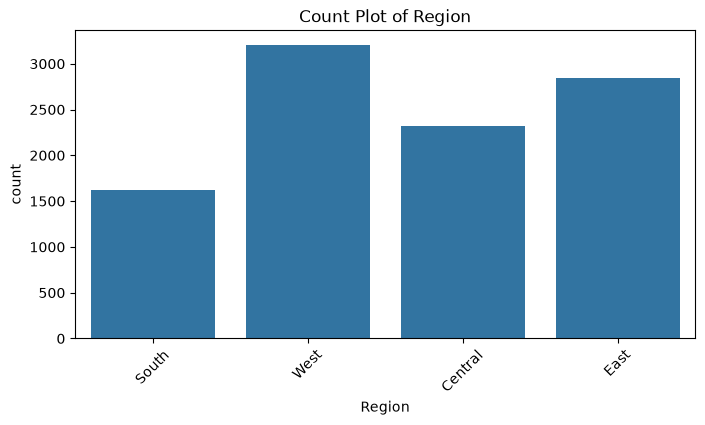

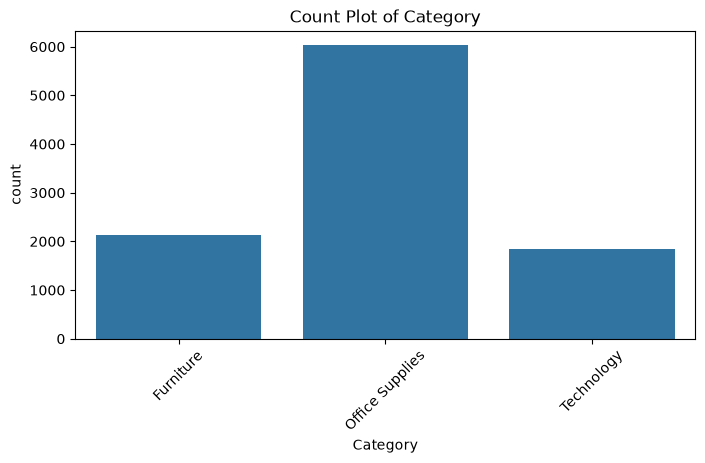

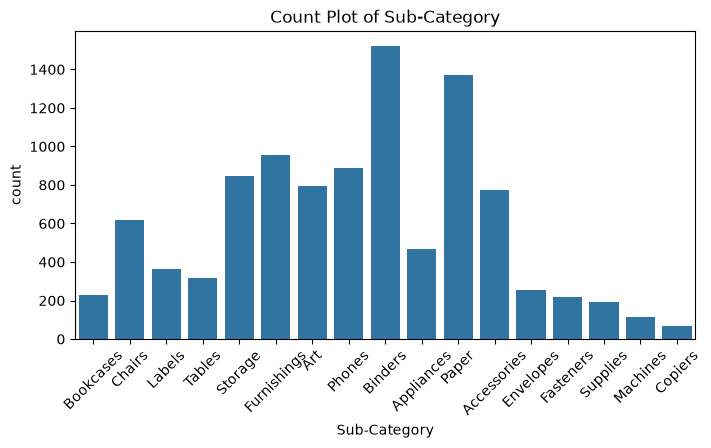

In [52]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

### Results

- The selected categorical variables were successfully visualized using count plots.
- Some categories occur much more frequently than others, indicating class imbalance.
- Filtering columns with fewer than 20 unique values produced clearer and more interpretable visualizations.

## Step 5: Distribution Analysis Summary

### Numeric Variables
- Histograms reveal the overall shape and spread of each numeric feature.
- Box plots highlight potential outliers, particularly in the **Profit** column.
- The IQR method successfully detected extreme values.
- Outliers were handled using **Winsorization (Capping)**, which preserves all observations while reducing the influence of extreme values.

### Categorical Variables
- Count plots display the frequency of each category.
- Some categorical features exhibit class imbalance, where certain categories occur much more frequently than others.
- Understanding these distributions is important before performing statistical analysis or building predictive models.